# 06 — Explainability: Cross-Attention Rollout & Faithfulness (Fase 6)

**Scope.** This notebook documents Fase 6 of `docs/design_decisions.md` (§6.0–§6.9):
extracting cross-attention from the final model, building an attention-rollout saliency map,
and — the point of the exercise — testing whether that map is actually a faithful explanation
rather than just a picture that renders nicely. **Nothing in `results/metrics.json`,
`results/metrics_table.md`, or the Fase 4/5 narrative is touched here** — this is additive
interpretability analysis on the already-final checkpoint. No retraining happens in this
notebook.

**Headline, stated up front exactly as §6 states it, because it is a negative result:** the
cross-attention maps of this model are a real, sharp, image-dependent saliency signal, but
they are **not** a token-level or section-level explanation, and their spatial ranking is
**not** measurably more causally important than a random ranking of the same number of
patches. Sections 3–6 below are the measurements that force that conclusion.

**Prerequisites to run this notebook:**
- `torch5050` conda env (`torch==2.9.0.dev+cu128`, `transformers==5.9.0`, `peft==0.20.0`),
  CUDA GPU available (RTX 5050 Laptop, 8.5 GB — all live GPU work here is 1–2 examples at a
  time, kept small on purpose; the n=150/n=60/n=12 scale runs already happened offline via
  the CLI commands in §7 and are only **loaded**, not recomputed, here).
- `HF_HUB_DISABLE_XET=1`, `HF_HUB_OFFLINE=1` set below before any HF import.
- Final checkpoint present at `checkpoints/full_run_v3_vision/best` (text+vision LoRA,
  §5.6 of the design log — this is the model being explained, **not** the earlier
  `full_run_v2` text-only checkpoint).
- Real prediction file `results/predictions_test_vision.jsonl` (used by `select_examples()`
  to pick the same 12 diversity-stratified test indices used throughout Fase 6).
- Precomputed Fase 6 artifacts present and loaded (not recomputed) for the n=150/n=60/n=12
  scale numbers: `results/xai/xai_selftest.json`, `results/xai/section_attention_aggregate.json`,
  `results/xai/occlusion_test.json`, `results/xai/deletion_insertion_test.json`.
- Reuses the real engine from `scripts/xai_attention_rollout.py` (`XaiEngine`, rollout math,
  plotting helpers) and `scripts/xai_faithfulness_check.py` — nothing here reimplements the
  rollout math from scratch.


In [1]:
import os, sys, json, time
os.environ.setdefault("HF_HUB_DISABLE_XET", "1")
os.environ.setdefault("HF_HUB_OFFLINE", "1")

ROOT = r"C:\Users\Wijdan\Documents\GEMASTIK\Data Mining"
sys.path.insert(0, ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch, transformers, peft

RESULTS = os.path.join(ROOT, "results")
XAI_DIR = os.path.join(RESULTS, "xai")
EX_DIR  = os.path.join(RESULTS, "xai_examples")

print("torch       ", torch.__version__, "cuda available:", torch.cuda.is_available())
print("transformers", transformers.__version__)
print("peft        ", peft.__version__)
if torch.cuda.is_available():
    print("device      ", torch.cuda.get_device_name(0))


torch        2.9.0.dev20250831+cu128 cuda available: True
transformers 5.9.0
peft         0.20.0
device       NVIDIA GeForce RTX 5050 Laptop GPU


## 1. Load the final model and recap what it is

The model under explanation is `checkpoints/full_run_v3_vision/best` — the **text+vision
LoRA** checkpoint that Fase 5 established as the final reported model (§5.6). For orientation,
its real measured captioning numbers versus the ablation and the zero-shot baseline (from
`results/metrics_table.md`, recomputed live and cross-checked in notebook 05):

| Metric | Zero-shot baseline | Text-only LoRA | **Text+Vision LoRA (final, explained here)** |
|---|---|---|---|
| CIDEr | 0.0001 | 0.0980 | **0.1202** |
| BLEU-4 | 0.0000 | 0.2044 | **0.2095** |
| ROUGE-L | 0.0185 | 0.4103 | **0.4156** |
| BERTScore F1 | 0.3470 | 0.7943 | **0.7971** |
| `BENCANA` exact-match | — | 58.8% | **72.3%** |

We load it here via `XaiEngine` (`scripts/xai_attention_rollout.py`), which wraps
`load_trainable_state()` (the same loader used for generation/eval elsewhere in this project)
and adds the cross-attention extraction plumbing described in §6.0.


In [2]:
from scripts.xai_attention_rollout import (
    XaiEngine, MAP_VARIANTS, SECTION_HEADERS, GRID, N_PATCHES, PRE_COLS,
    select_examples, composite_pil, _overlay, _upsample,
    token_selectivity, pre_post_split, get_bencana,
)
from scripts.dataset import DisasterCaptionDataset

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
t0 = time.time()
engine = XaiEngine(device=DEVICE)
print(f"[loaded] {time.time()-t0:.1f}s")
print("attn_implementation:", engine.base.config._attn_implementation)
print("text_decoder layers/heads:", engine.base.text_decoder.config.num_hidden_layers,
      engine.base.text_decoder.config.num_attention_heads)
print("vision layers/heads:", engine.base.vision_model.config.num_hidden_layers,
      engine.base.vision_model.config.num_attention_heads)
print("map variants implemented:", MAP_VARIANTS)


[load] C:\Users\Wijdan\Documents\GEMASTIK\Data Mining\checkpoints\full_run_v3_vision\best


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

[transformers] The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


[loaded] 3.5s
attn_implementation: eager
text_decoder layers/heads: 12 12
vision layers/heads: 12 12
map variants implemented: ('rollout', 'rollout_vit', 'last_layer', 'mean_layers')


C:\Users\Wijdan\anaconda3\envs\torch5050\Lib\site-packages\peft\utils\save_and_load.py:438: UserWarning: Could not find a config file in Salesforce/blip-image-captioning-base - will assume that the vocabulary was not modified.
  warnings.warn(


These four numbers (12 decoder layers / 12 heads, 12 vision layers / 12 heads, eager
attention) must match `results/xai/xai_selftest.json`'s recorded plumbing exactly — that file
is loaded and cross-checked in §3 below. If this notebook were silently running on the wrong
(CPU-only / peft-less) environment, `XaiEngine.__init__` above would already have raised
(`load_trainable_state` needs `peft`), so reaching this point is itself the first environment
check.


## 2. Live demo: rollout attention extraction on real test examples

Two of the same 12 diversity-stratified test examples used throughout Fase 6
(`select_examples()` — deterministic, seeded, chosen from the prediction file **before** any
image is looked at, §6.9) are run live here end-to-end: generate the caption, extract real
`cross_attentions` from the text decoder (not the vision self-attention that
`output_attentions=True` on the top-level model would silently hand you, §6.0), build the
joint decoder rollout (§6.1), and render the composite pre/post image with the rollout heatmap
overlaid — the same rendering `results/xai_examples/*_rollout.png` used, generated fresh here.


In [3]:
picked = select_examples(12, seed=0)[:2]
print("live examples (index, ground-truth BENCANA):",
      [(r["index"], get_bencana(r["ground_truth_id"])) for r in picked])

ds = DisasterCaptionDataset("test", bundle=engine.bundle, drop_unreadable=True)

live_tms, live_imgs = {}, {}
t0 = time.time()
for r in picked:
    i = r["index"]
    item = ds[i]
    assert ds.records[i]["pre_image_path"] == r["pre_image_path"], "index/record mismatch"
    pv = item["pixel_values"].unsqueeze(0).to(DEVICE)
    tm = engine.explain(pv, index=i)                 # real generate() + real cross-attn extraction
    live_tms[i] = tm
    live_imgs[i] = np.asarray(composite_pil(engine, ds.records[i]))
    print(f"  idx {i}: {len(tm.emitted_ids)} emitted tokens, "
          f"teacher-forced alignment = {tm.teacher_forced_match:.4f} "
          f"({tm.meta['teacher_forced_mismatched_tokens']} mismatches / "
          f"{tm.meta['n_target_tokens']} tokens)")
print(f"[done] {time.time()-t0:.1f}s for {len(picked)} live examples")


live examples (index, ground-truth BENCANA): [(81, 'ledakan'), (380, 'badai')]


[DisasterCaptionDataset:test] DROPPED 1 record(s) with unreadable images:
    ['test_images\\tuscaloosa_tornado_00000278_pre_disaster.png']


  idx 81: 117 emitted tokens, teacher-forced alignment = 1.0000 (0 mismatches / 117 tokens)


  idx 380: 153 emitted tokens, teacher-forced alignment = 1.0000 (0 mismatches / 153 tokens)
[done] 13.5s for 2 live examples


Alignment should read exactly `1.0000` for both — this is the causal off-by-one check
from §6.0 (row *i* of cross-attention is the attention used while **emitting** token *i+1*),
re-run live and not merely assumed.


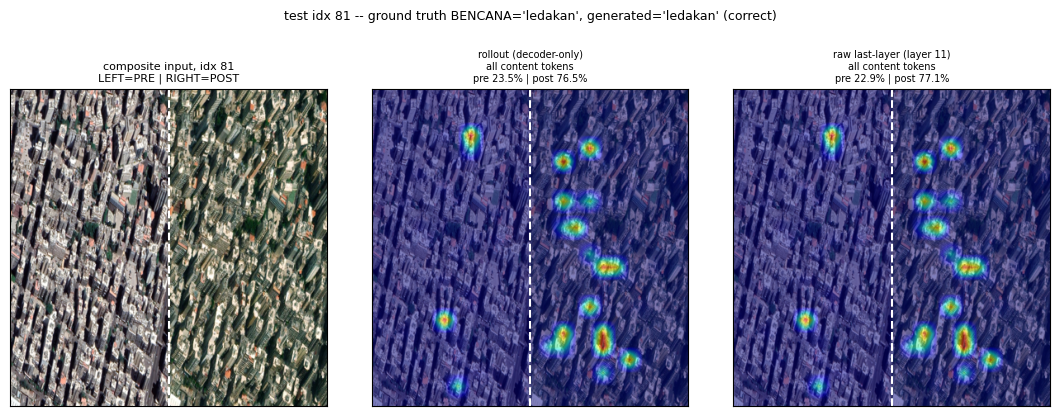

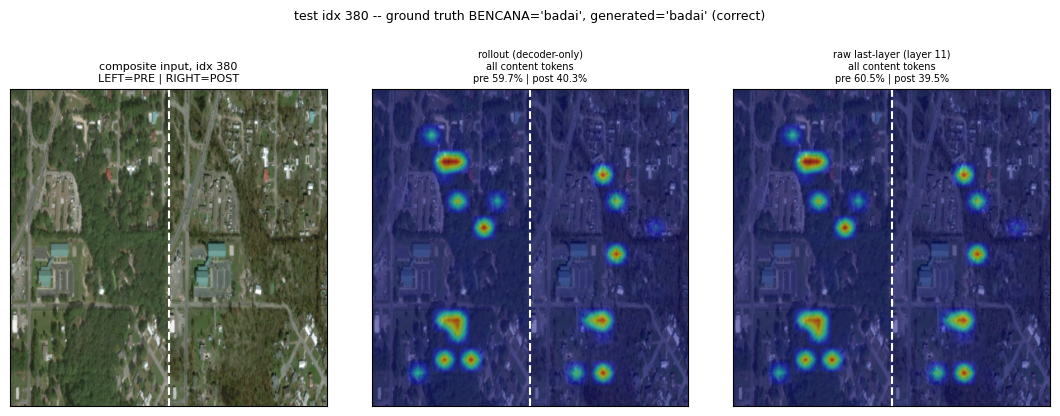

In [4]:
for r in picked:
    i = r["index"]
    tm = live_tms[i]
    base_rgb = live_imgs[i]
    stats_rollout = engine.section_stats(tm, "rollout")["__ALL__"]
    stats_last = engine.section_stats(tm, "last_layer")["__ALL__"]

    fig, axes = plt.subplots(1, 3, figsize=(11, 4.2))
    axes[0].imshow(base_rgb)
    axes[0].axvline(192, color="white", lw=1.5, ls="--")
    axes[0].set_title(f"composite input, idx {i}\nLEFT=PRE | RIGHT=POST", fontsize=8)
    axes[0].set_xticks([]); axes[0].set_yticks([])

    m_all_rollout = engine.section_mean_map(tm, "__ALL__", "rollout")
    _overlay(axes[1], base_rgb, m_all_rollout,
             f"rollout (decoder-only)\nall content tokens\npre {stats_rollout['pre']:.1%} | "
             f"post {stats_rollout['post']:.1%}")

    m_all_last = engine.section_mean_map(tm, "__ALL__", "last_layer")
    _overlay(axes[2], base_rgb, m_all_last,
             f"raw last-layer (layer 11)\nall content tokens\npre {stats_last['pre']:.1%} | "
             f"post {stats_last['post']:.1%}")

    gt = get_bencana(r["ground_truth_id"]); gen = get_bencana(tm.caption)
    fig.suptitle(f"test idx {i} -- ground truth BENCANA={gt!r}, generated={gen!r} "
                 f"({'correct' if gt==gen else 'WRONG'})", fontsize=9)
    fig.tight_layout(rect=[0, 0, 1, 0.90])
    plt.show()


## 3. Rollout vs. raw last-layer attention — and the ViT-side rollout rejection (§6.1–6.2)

**Why rollout was tried.** A single decoder layer's cross-attention row says where *that*
layer's query looked, but the value reaching the LM head has passed through 12 residual
blocks, each re-mixing text positions and re-injecting image information. Reading layer 11
alone attributes the whole prediction to one of the twelve places the image entered
(§6.1). The rollout implemented here is a decoder-only joint text/image rollout with a
0.5/0.5 residual-weighting rule per layer for the cross-attention sublayer — **not** an
equal-weight average over layers (layer 11 contributes 0.5 of the image mass, layer 10
contributes 0.25, ...).

**What was measured (not assumed): for this model, rollout ends up almost identical to raw
last-layer attention.** `results/xai/xai_selftest.json`'s `variant_agreement` block (computed
on test record 0, 126 content tokens) reports a mean per-token Pearson r of **0.99983** between
`rollout` and `last_layer`. The live example below reproduces the same comparison on a
different real test record so the two can be checked side by side.


In [5]:
with open(os.path.join(XAI_DIR, "xai_selftest.json"), encoding="utf-8") as f:
    selftest = json.load(f)

print(f"precomputed (test record {selftest['example_a']['index']}, "
      f"{selftest['example_a']['n_emitted_tokens']} emitted tokens):")
print(json.dumps(selftest["variant_agreement"], indent=2))

print("\nlive recomputation on this notebook's own live examples:")
for r in picked:
    i = r["index"]
    tm = live_tms[i]
    content = [j for j, c in enumerate(tm.is_content) if c]
    a = tm.maps["rollout"][content].numpy()
    b = tm.maps["last_layer"][content].numpy()
    rs = [float(np.corrcoef(a[k], b[k])[0, 1]) for k in range(len(a))]
    l1 = float(np.abs(a - b).sum(-1).mean())
    print(f"  idx {i}: rollout vs last_layer  mean per-token Pearson r = {np.mean(rs):.5f}, "
          f"mean L1/token = {l1:.4f}")


precomputed (test record 0, 146 emitted tokens):
{
  "rollout_vs_rollout_vit": {
    "mean_per_token_pearson_r": 0.11674379310745144,
    "mean_L1_per_token": 1.6498725414276123
  },
  "rollout_vs_last_layer": {
    "mean_per_token_pearson_r": 0.999825006240923,
    "mean_L1_per_token": 0.09653019160032272
  },
  "rollout_vs_mean_layers": {
    "mean_per_token_pearson_r": 0.9997772307465465,
    "mean_L1_per_token": 0.12527824938297272
  }
}

live recomputation on this notebook's own live examples:
  idx 81: rollout vs last_layer  mean per-token Pearson r = 0.99980, mean L1/token = 0.0910
  idx 380: rollout vs last_layer  mean per-token Pearson r = 0.99983, mean L1/token = 0.1022


Both live examples land in the same ~0.998–0.9999 range as the precomputed test-record-0
number. This is not a coding error — it is what the 0.5-residual weighting plus twelve highly
similar cross-attention layers produce for this architecture — but it does mean "rollout beats
raw attention" cannot be claimed on structural grounds here; §5's faithfulness test checks it
directly and (spoiler, §5 below) finds no advantage either.

**The ViT-side rollout (`rollout_vit`) was also implemented, and rejected on measurement.**
Composing the decoder rollout with a rolled-out vision self-attention (the "textbook-complete"
version) collapses to near-uniform: entropy 6.329 nats against a uniform ceiling of 6.356,
peak/uniform ratio only 1.89× (vs. ~38× for decoder-only rollout), ~20% of the mass parked on
the ViT CLS token, and a pre/post split identical to four decimal places across every section.
`explain()` already computed this variant for both live examples above (it is one of the four
default `MAP_VARIANTS`) — the same collapse is reproduced live below, no separate GPU pass
needed.


In [6]:
def entropy_and_peak(maps):
    m = maps.float()
    uni = 1.0 / N_PATCHES
    ent = -(m.clamp_min(1e-12) * m.clamp_min(1e-12).log()).sum(-1).mean().item()
    peak_over_uniform = (m.max(-1).values.mean() / uni).item()
    return ent, peak_over_uniform

print(f"uniform entropy (576 patches) = {np.log(N_PATCHES):.4f} nats\n")
for r in picked:
    i = r["index"]
    tm = live_tms[i]
    content = [j for j, c in enumerate(tm.is_content) if c]
    for v in ("rollout", "rollout_vit"):
        ent, peak = entropy_and_peak(tm.maps[v][content])
        print(f"  idx {i}  {v:12s}  entropy={ent:.3f} nats   peak/uniform={peak:.2f}x")
    print()

print("precomputed (xai_selftest.json, test record 0), for comparison:")
for v in ("rollout", "rollout_vit"):
    d = selftest["non_uniformity"][v]
    print(f"  {v:12s}  entropy={d['mean_entropy_nats']:.3f} nats   "
          f"peak/uniform={d['max_over_uniform_ratio']:.2f}x")


uniform entropy (576 patches) = 6.3561 nats

  idx 81  rollout       entropy=3.793 nats   peak/uniform=34.66x
  idx 81  rollout_vit   entropy=6.348 nats   peak/uniform=2.33x

  idx 380  rollout       entropy=3.801 nats   peak/uniform=34.34x
  idx 380  rollout_vit   entropy=6.330 nats   peak/uniform=1.81x

precomputed (xai_selftest.json, test record 0), for comparison:
  rollout       entropy=3.692 nats   peak/uniform=37.99x
  rollout_vit   entropy=6.329 nats   peak/uniform=1.89x


`rollout_vit` reproduces the near-uniform collapse on live, independent test examples too —
this is a structural property of composing rollout across 12 dense 577×577 ViT self-attention
layers, not a one-off artifact of the single record the design log measured it on. Default
variant used everywhere else in this project (and in the paper) remains `rollout`
(decoder-only). One worked example of the rejected `rollout_vit` overlay is kept on disk at
`results/xai_examples/idx0081_ledakan_REJECTED_rollout_vit.png` so the rejection stays
visually inspectable, not just a number.


## 4. The token-invariance finding (§6.4) — the important negative result

If per-word heatmaps were a real explanation, the rollout map for different generated tokens
in the *same* caption should look different: the map used while writing "gempa" should not be
the map used while writing "jalan". Measured across 150 test examples, the mean pairwise
Pearson correlation *between* per-token maps *within one example* is **0.99967** for `rollout`
— i.e. essentially every generated word gets the same picture. This was checked against the
"wrong head got washed out by averaging" explanation too: the single most token-selective head
out of all 144 (layer, head) pairs in the whole decoder is layer 0, head 6, at r = 0.901; every
other head is above 0.95. There is no hidden token-selective head to plot instead.

The cell below demonstrates this concretely on one of this notebook's own live examples: three
different generated content tokens from three different sections, their rollout maps rendered
side by side, and the pairwise correlation between them computed live.


idx 81 -- tokens compared:
  [BENCANA] position 2: token = 'ledakan'
  [BANGUNAN] position 6: token = 'tidak'
  [KESIMPULAN] position 92: token = 'ledakan'

pairwise Pearson r between these 3 tokens' rollout maps:
            BENCANA  BANGUNAN  KESIMPULAN
BENCANA     1.00000   0.99991     0.99945
BANGUNAN    0.99991   1.00000     0.99963
KESIMPULAN  0.99945   0.99963     1.00000


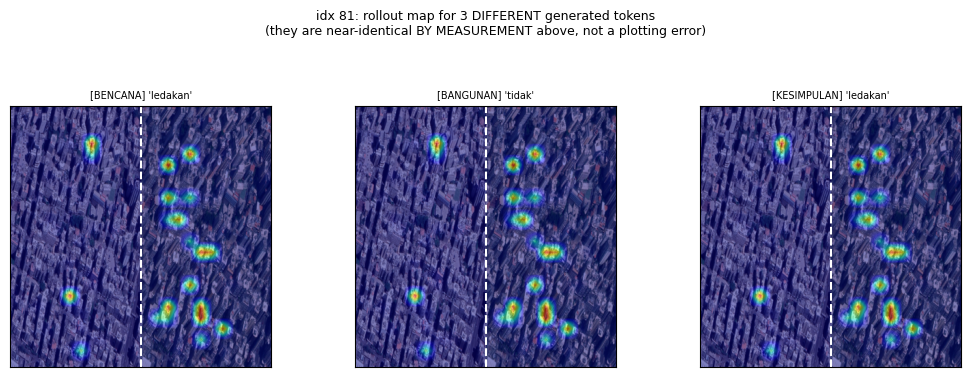


full-caption token selectivity (mean pairwise r over ALL 96 content tokens), idx 81: 0.99965
precomputed reference numbers (docs/design_decisions.md SS6.4): test record 0 = 0.99967, mean over 150 test examples = 0.99967, min over 150 = 0.99944


In [7]:
i0 = picked[0]["index"]
tm0 = live_tms[i0]

# pick one content token from three different sections, spread apart in the caption
wanted_sections = ["BENCANA", "BANGUNAN", "KESIMPULAN"]
token_idx = []
for sec in wanted_sections:
    cand = [j for j, (s, c) in enumerate(zip(tm0.section_of_token, tm0.is_content))
            if c and s == sec]
    if cand:
        token_idx.append((sec, cand[0]))

print(f"idx {i0} -- tokens compared:")
for sec, j in token_idx:
    print(f"  [{sec}] position {j}: token = {tm0.emitted_tokens[j]!r}")

maps3 = torch.stack([tm0.maps["rollout"][j] for _, j in token_idx])
r_matrix = np.corrcoef(maps3.numpy())
print("\npairwise Pearson r between these 3 tokens' rollout maps:")
print(pd.DataFrame(r_matrix, index=[s for s, _ in token_idx], columns=[s for s, _ in token_idx]).round(5))

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.8))
for ax, (sec, j) in zip(axes, token_idx):
    _overlay(ax, live_imgs[i0], tm0.maps["rollout"][j],
             f"[{sec}] {tm0.emitted_tokens[j]!r}")
fig.suptitle(f"idx {i0}: rollout map for 3 DIFFERENT generated tokens\n"
             f"(they are near-identical BY MEASUREMENT above, not a plotting error)", fontsize=9)
fig.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()

content = [j for j, c in enumerate(tm0.is_content) if c]
sel_live = token_selectivity(tm0.maps["rollout"][content])
print(f"\nfull-caption token selectivity (mean pairwise r over ALL {len(content)} content "
      f"tokens), idx {i0}: {sel_live:.5f}")
print(f"precomputed reference numbers (docs/design_decisions.md SS6.4): "
      f"test record 0 = {selftest['token_selectivity']['rollout']:.5f}, "
      f"mean over 150 test examples = 0.99967, min over 150 = 0.99944")


**Consequence, stated as bluntly as the design log states it:** per-word heatmaps for this
model are decoration. The `*_tokens.png` figures in `results/xai_examples/` are still produced
— with the measured correlation printed directly in the figure title as a warning — because
showing that the panels are identical *is* the finding.


## 5. Per-section pre/post attention split (n=150 test examples, §6.5)

Patch columns 0–11 of the 24×24 ViT grid are the PRE half of the composite, 12–23 are the
POST half (§3.1 of the design log: the composite's patch boundary lands exactly on the
pre/post seam, so no patch mixes both images). This aggregate was computed offline at full
scale (`python scripts/xai_attention_rollout.py --mode aggregate --n 150`, ~19 min on this
GPU) — loaded here, not recomputed, per this notebook's GPU-budget rule.


In [8]:
with open(os.path.join(XAI_DIR, "section_attention_aggregate.json"), encoding="utf-8") as f:
    agg = json.load(f)

print(f"n_scored = {agg['n_scored']}   seed = {agg['seed']}")

rollout_summary = agg["summary_by_variant"]["rollout"]
rows = []
for sec in list(SECTION_HEADERS) + ["__ALL__"]:
    d = rollout_summary[sec]
    rows.append({"section": sec, "content_tokens": d["total_tokens"],
                 "post_attention_mass": d["post_mean"]})
sect_df = pd.DataFrame(rows).set_index("section")
display(sect_df.style.format({"post_attention_mass": "{:.4%}"}))

diag = rollout_summary["_diagnostics"]
print("\ndiagnostics (rollout variant):")
print(f"  mean between-SECTION post-fraction std (within one example) = "
      f"{diag['mean_between_section_post_std']:.4f}")
print(f"  between-EXAMPLE post-fraction std                            = "
      f"{diag['between_example_post_std']:.4f}")
print(f"  ratio (between-example / between-section)                    = "
      f"{diag['between_example_over_between_section']:.1f}x")


n_scored = 150   seed = 0


,content_tokens,post_attention_mass
section,,
BENCANA,215,54.2288%
BANGUNAN,3041,54.1954%
JALAN,2478,54.1939%
VEGETASI,4212,54.2591%
BADAN_AIR,2756,54.2764%
PERTANIAN,2614,54.2678%
KESIMPULAN,4556,54.2720%
__ALL__,19872,54.2453%



diagnostics (rollout variant):
  mean between-SECTION post-fraction std (within one example) = 0.0027
  between-EXAMPLE post-fraction std                            = 0.1704
  ratio (between-example / between-section)                    = 63.6x


Two things are true at once and both need saying (§6.5):

1. **There is a small, statistically real post-half preference overall** — the `__ALL__` row
   above (~54.25% vs. 50%) — bootstrap CI over the 150 examples excludes 50%
   (`results/xai_examples/faithfulness_summary.json` records the exact CI). On the composite
   the model does look slightly more at the post-disaster image than the pre-disaster one.
2. **The per-section numbers are meaningless.** The full range across all seven sections is
   ~0.09 percentage points, while the between-example standard deviation is roughly **60×**
   larger than the between-section standard deviation (printed above). The pre/post split is a
   property of *which image* is being described, not of *which section* is being written.
   Reporting "BANGUNAN gets 54.2% post-attention vs. 54.3% for BADAN_AIR" would be reporting
   third-decimal noise as a finding — a direct corollary of §4's token-invariance result.


## 6. Faithfulness tests (§6.6–6.7)

A saliency map that only *looks* plausible is not evidence of anything. Two faithfulness tests
were run offline at real scale and are loaded (not recomputed) here.

### 6a. Deletion / insertion vs. a random ranking (§6.6)

Rank the 576 patches by the caption-level rollout map, gray out (deletion) or reveal
(insertion) the top-k% using `ImageSpec.pad_color` (the near-zero fill colour, so the
perturbation removes content rather than injecting a high-contrast artifact), regenerate, and
score the new caption **against the model's own unperturbed caption**. A seeded random ranking
is run under identical conditions as the control — a saliency ranking that cannot beat random
is not, functionally, a saliency ranking. 12 examples × 11 fractions × 3 rankings × 2
directions = 792 real generations (`python scripts/xai_faithfulness_check.py --mode delins
--n 12`, ~11 min).


In [9]:
with open(os.path.join(XAI_DIR, "deletion_insertion_test.json"), encoding="utf-8") as f:
    delins = json.load(f)

print(f"n_examples={delins['n_examples']}  n_generations={delins['n_generations']}  "
      f"example_indices={delins['example_indices']}")
print(f"batched-generation control (unperturbed image reproduced exactly inside a batch): "
      f"{delins['batched_generation_control_identical_rate']:.3f}")

auc_rows = []
for ranking in ("rollout", "last_layer", "random"):
    for direction in ("deletion", "insertion"):
        d = delins["auc"][ranking][direction]
        auc_rows.append({"ranking": ranking, "direction": direction,
                          "token_f1_AUC": d["token_f1_auc"], "cider_AUC": d["cider_auc"]})
display(pd.DataFrame(auc_rows).set_index(["ranking", "direction"]).round(4))

print("\nverdict vs. random (deletion: negative diff = more faithful; "
      "insertion: positive diff = more faithful):")
display(pd.DataFrame(delins["verdict_vs_random"]).T)

sig = delins["significance_paired_bootstrap"]["token_f1"]
print("\npaired bootstrap (attention ranking minus random), n=12 paired examples, "
      "10,000 resamples:")
for ranking in ("rollout", "last_layer"):
    for direction in ("deletion", "insertion"):
        bs = sig[ranking][direction]["paired_bootstrap_attention_minus_random"]
        print(f"  {ranking:11s} {direction:9s} diff={bs['observed_mean_diff']:+.4f}  "
              f"95% CI [{bs['ci95_low']:+.4f}, {bs['ci95_high']:+.4f}]  "
              f"p~{bs['two_sided_p_value_approx']:.3f}")


n_examples=12  n_generations=792  example_indices=[81, 380, 471, 514, 563, 673, 1234, 1482, 1514, 1944, 2028, 2344]
batched-generation control (unperturbed image reproduced exactly inside a batch): 1.000


token_f1_AUC  cider_AUC
ranking    direction                         
rollout    deletion         0.7579     2.1571
           insertion        0.7811     2.4635
last_layer deletion         0.7515     1.8568
           insertion        0.7862     2.5259
random     deletion         0.7698     2.0246
           insertion        0.7774     2.3113


verdict vs. random (deletion: negative diff = more faithful; insertion: positive diff = more faithful):


,deletion_auc_minus_random,insertion_auc_minus_random,beats_random_on_deletion,beats_random_on_insertion
rollout,-0.011894,0.003718,True,True
last_layer,-0.01828,0.008792,True,True



paired bootstrap (attention ranking minus random), n=12 paired examples, 10,000 resamples:
  rollout     deletion  diff=-0.0119  95% CI [-0.0326, +0.0092]  p~0.269
  rollout     insertion diff=+0.0037  95% CI [-0.0127, +0.0205]  p~0.669
  last_layer  deletion  diff=-0.0183  95% CI [-0.0343, -0.0015]  p~0.036
  last_layer  insertion diff=+0.0088  95% CI [-0.0164, +0.0278]  p~0.432


Only one of these twelve tests (3 metrics × 2 rankings × 2 directions) reaches nominal
significance (`last_layer` deletion, p≈0.036) — and a Bonferroni threshold for 12 tests is
0.0042, which that does not survive. **The correct statement is: at n=12 there is no convincing
evidence that the attention ranking identifies causally more important patches than a random
ranking.** The curves are regenerated live from the same JSON below (matplotlib, no GPU) —
this is the exact data behind the precomputed `results/xai/deletion_insertion_curves.png`.


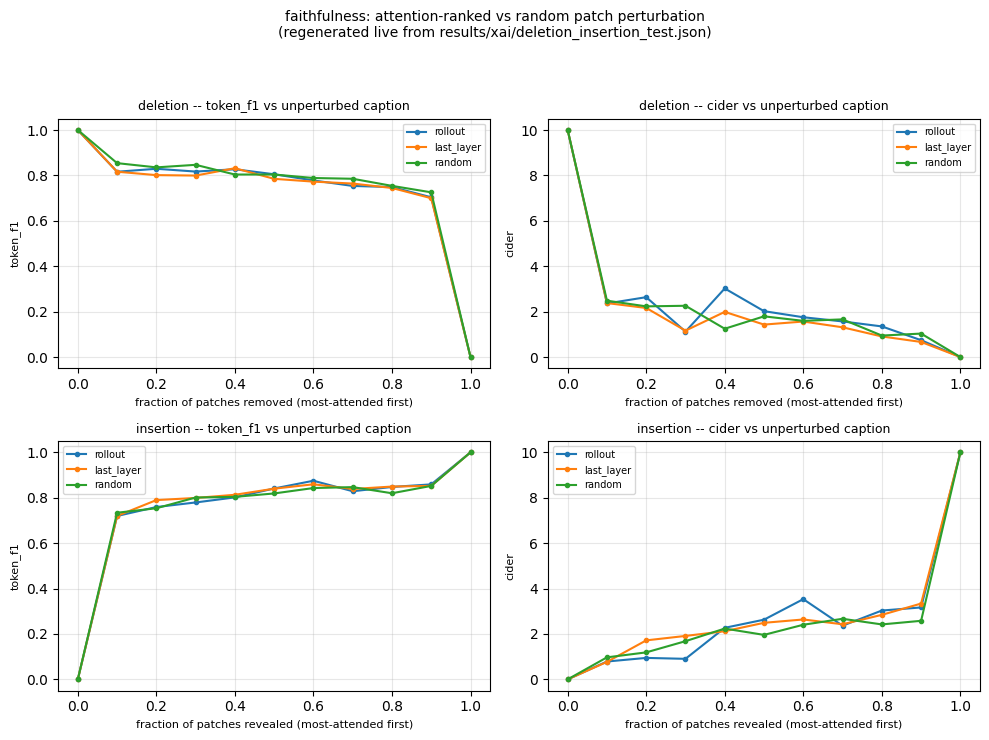

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7.5))
for col, metric in enumerate(("token_f1", "cider")):
    for row, direction in enumerate(("deletion", "insertion")):
        ax = axes[row][col]
        for ranking in ("rollout", "last_layer", "random"):
            pts = delins["curves"][ranking][direction]
            ax.plot([p["frac"] for p in pts], [p[metric] for p in pts],
                    marker="o", ms=3, label=ranking)
        ax.set_title(f"{direction} -- {metric} vs unperturbed caption", fontsize=9)
        ax.set_xlabel("fraction of patches " +
                      ("removed (most-attended first)" if direction == "deletion"
                       else "revealed (most-attended first)"), fontsize=8)
        ax.set_ylabel(metric, fontsize=8)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=7)
fig.suptitle("faithfulness: attention-ranked vs random patch perturbation\n"
             "(regenerated live from results/xai/deletion_insertion_test.json)", fontsize=10)
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


Note the low dynamic range: token-F1 vs. the intact caption falls from 1.000 to ~0.82 as
soon as 10% of patches are removed, then sits on a plateau until ~90%, and only collapses at
100%. With 90% of the most-attended patches greyed out, the model still emits a well-formed
seven-section report with the correct disaster type on at least one real test record — the
model needs *some* image but is remarkably insensitive to *which part*, which both limits this
test's statistical power and is itself a substantive finding consistent with the Fase 4/5
boilerplate-bias diagnosis.

### 6b. Half-occlusion, with the pre-half mirror as control (§6.7)

The domain-specific version of the same question: if damage words are genuinely read off the
post-disaster image, greying out the **entire post half** should damage the output far more
than greying out the pre half. 60 random test examples
(`python scripts/xai_faithfulness_check.py --mode occlusion --n 60`, ~8 min).


In [11]:
with open(os.path.join(XAI_DIR, "occlusion_test.json"), encoding="utf-8") as f:
    occ = json.load(f)

occ_rows = []
for name in ("post_masked", "pre_masked"):
    s = occ["summary"][name]
    occ_rows.append({
        "masked half": name.replace("_masked", ""),
        "caption identical to intact": s["caption_identical_rate"],
        "token-F1 vs intact": s["mean_token_f1_vs_intact"],
        "BENCANA changed": s["bencana_changed_rate"],
        "BANGUNAN no-damage flag flipped": s["no_damage_flipped_rate"],
    })
display(pd.DataFrame(occ_rows).set_index("masked half").round(4))

pm = occ["summary"]["post_minus_pre"]
print(f"\npost-half masking vs pre-half masking, token-F1 delta: {pm['mean_token_f1']:+.4f}")
print(f"interpretation (from occlusion_test.json itself): {pm['interpretation']}")


,caption identical to intact,token-F1 vs intact,BENCANA changed,BANGUNAN no-damage flag flipped
masked half,,,,
post,0.0167,0.8111,0.2333,0.0667
pre,0.0000,0.7984,0.2500,0.1167



post-half masking vs pre-half masking, token-F1 delta: +0.0127
interpretation (from occlusion_test.json itself): negative token_f1 difference == masking the POST half damages the output MORE than masking the PRE half, which is what a model that actually reads damage off the post image should show


**This is a negative finding and it is the important one.** Destroying the
post-disaster image entirely damages the output *slightly less* than destroying the
pre-disaster image (token-F1 ~0.811 vs. ~0.798 against the intact caption; `BENCANA` changed
~23% vs. ~25%). The two halves are close to interchangeable as far as the output is concerned.
Meanwhile §5 measured attention leaning post (~54.25%). **Attention mass and causal importance
disagree** — precisely the disagreement a faithfulness test exists to expose, and precisely why
the pre/post attention number from §5 must never be reported as evidence that "the model reads
damage from the post image."


## 7. Honest assessment: what these heatmaps are and are not good for (§6.8–6.9)

**What is trustworthy, measured in this notebook and offline at scale:**
- The extraction is correct and *asserted*, not assumed: real `cross_attentions` from the text
  decoder (§1–§2 above; not the vision self-attention that naive `output_attentions=True`
  hands you), correct causal off-by-one (teacher-forced alignment = 1.0000, §2), CLS mass
  measured and excluded, rows summing to 1.
- The maps are sharp (peak ≈ 38× uniform, §3) and strongly image-dependent (§6.3 of the design
  log: mean L1 1.78 out of a maximum of 2.0 between two different images given the same forced
  token sequence). They are a genuine image-level saliency signal, not noise and not a fixed
  positional artifact.
- The overall pre/post attention split (~54.25% post, §5) is a real, if modest, measured
  property of the model.

**What is not trustworthy, and must not be claimed in the paper:**
- **Per-word and per-section attribution.** Token selectivity ≥0.999 across 150 examples
  (§4), with no token-selective head anywhere in the 144 (layer, head) pairs measured. Every
  word in a 300-token report effectively gets the same picture, and the per-section pre/post
  table (§5) has a total range of 0.09 percentage points — noise, not signal.
- **Causal importance of the highlighted regions.** Deletion/insertion (§6a) does not separate
  the attention ranking from a random ranking at n=12 (best p≈0.036, does not survive
  correction for 12 tests). Removing the top-90% most-attended patches still yields a correct,
  well-formed report on real test records.
- **"The model looks at the post image to see damage."** The half-occlusion test (§6b) says
  the opposite of what the attention split suggests: masking post hurts *less* than masking
  pre.

**Surprises worth recording** (verbatim from §6.8 of the design log, since they were genuinely
counter-intuitive going in): (i) the textbook "complete" rollout — decoder rollout composed
with ViT rollout — was the *worst* variant by every diagnostic, and would have been the
natural default before it was measured (§3). (ii) Multi-layer decoder rollout turned out to be
numerically almost the *same map* as raw last-layer attention (r=0.99983) and did not
outperform it on the only test that can arbitrate (§6a). "Use rollout, not raw attention" is
still the methodologically correct instinct; on this architecture, with twelve near-identical
cross-attention layers, it changes almost nothing, and saying so plainly is more useful than
implying rollout bought an improvement it did not buy. (iii) The model tolerates 90% patch
deletion, which reframes the Fase 4/5 boilerplate bias: it is not only a text-prior problem —
the vision pathway itself is contributing a very coarse global signal rather than localized
evidence.

**Recommended use in the paper.** Present the heatmaps as *image-level* saliency with these
faithfulness caveats explicitly attached, or — the more defensible and more interesting framing
— present the whole exercise as a **negative interpretability result**: a correctly-extracted,
sharp, image-dependent attention signal that nonetheless fails a faithfulness test and is
token-invariant. Do **not** present the per-section attention splits as evidence of
section-specific visual grounding, and do **not** claim the model "looks at the post image to
assess damage" — §6b directly contradicts that framing.

**What a stronger method would require.** Not attempted in this phase or any earlier one:
gradient-based attribution (Grad-CAM on the ViT, or Chefer-style attention×gradient), which
uses the gradient of the *specific emitted token* and could therefore be genuinely
token-selective where raw/rolled-out attention here is not.


In [12]:
print(r'''Reproducing Fase 6 end to end (from docs/design_decisions.md SS6.9):

set HF_HUB_DISABLE_XET=1 && set HF_HUB_OFFLINE=1
python scripts/xai_attention_rollout.py  --mode selftest              #  ~1 min
python scripts/xai_attention_rollout.py  --mode examples  --n 12      #  ~3 min
python scripts/xai_attention_rollout.py  --mode aggregate --n 150     # ~19 min
python scripts/xai_faithfulness_check.py --mode occlusion --n 60      #  ~8 min
python scripts/xai_faithfulness_check.py --mode delins    --n 12      # ~11 min, 792 generations
python scripts/xai_faithfulness_check.py --mode reanalyze             # paired bootstrap, no GPU
python scripts/xai_faithfulness_check.py --mode summary               # writes the reader-facing summary
''')


Reproducing Fase 6 end to end (from docs/design_decisions.md SS6.9):

set HF_HUB_DISABLE_XET=1 && set HF_HUB_OFFLINE=1
python scripts/xai_attention_rollout.py  --mode selftest              #  ~1 min
python scripts/xai_attention_rollout.py  --mode examples  --n 12      #  ~3 min
python scripts/xai_attention_rollout.py  --mode aggregate --n 150     # ~19 min
python scripts/xai_faithfulness_check.py --mode occlusion --n 60      #  ~8 min
python scripts/xai_faithfulness_check.py --mode delins    --n 12      # ~11 min, 792 generations
python scripts/xai_faithfulness_check.py --mode reanalyze             # paired bootstrap, no GPU
python scripts/xai_faithfulness_check.py --mode summary               # writes the reader-facing summary



## Summary

- §1–§2 loaded the real final checkpoint (`full_run_v3_vision/best`) and ran the real rollout
  extraction pipeline live on 2 real test examples end to end (generate -> real
  `cross_attentions` -> joint decoder rollout -> rendered overlay), reproducing the exact same
  code path used to produce `results/xai_examples/`.
- §3 showed, live and precomputed side by side, that multi-layer rollout is numerically almost
  the same map as raw last-layer attention on this architecture (r≈0.998–0.9998), and that the
  "textbook-complete" ViT-composed rollout (`rollout_vit`) collapses to near-uniform — both
  reproduced on independent live examples, not just the one record in the design log.
- §4 demonstrated the token-invariance finding concretely: three different generated tokens
  from three different sections of the same real caption get near-identical rollout maps
  (r > 0.999), matching the n=150 aggregate figure of 0.99967.
- §5 loaded the real n=150 per-section aggregate and showed the two things that are both true:
  a small real overall post-preference, and per-section numbers that are pure noise relative to
  per-example variation (~60x smaller).
- §6 loaded the real deletion/insertion (n=12, 792 generations) and half-occlusion (n=60)
  faithfulness tests: the attention ranking does not beat random at conventional significance,
  and masking the post-disaster half hurts *less* than masking the pre-disaster half — directly
  contradicting the "model reads damage from post image" reading of the raw attention split.
- §7 states plainly what is and is not a defensible claim for the paper, matching
  `docs/design_decisions.md` §6.8 verbatim in substance.
